In [7]:
from numpy import linspace
from scipy.integrate import odeint, solve_ivp
from matplotlib.pyplot import subplots

# Model of Calcium Oscillations

Paper: [Kummer et al 2000, Biophys J]([https://www.sciencedirect.com/science/article/pii/S0006349500763739?ref=pdf_download&fr=RR-2&rr=9225ed79fc82f660)


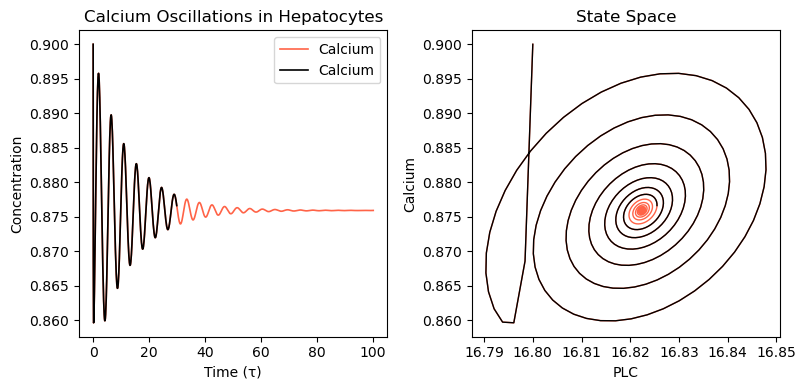

In [17]:

# Define the model equations
def model(t, y, params):
    c1, c2, c3 = y  # Unpack variables
    k1, k2, k3, k4, k5, k6, k7, k8, k9, k10, k11, k12 = params  # Unpack parameters

    # if t > 30:

    #     k1 = 0.5
    
    # Define the differential equations
    dc1_dt = k1 + k2*c1 - k3*c1*c2/(k4  + c1) - k5*c1*c3/(k6 + c1)
    dc2_dt =      k7*c1 - k8   *c2/(k9  + c2)   
    dc3_dt =      k10*c1- k11  *c3/(k12 + c3)
    
    return [dc1_dt, dc2_dt, dc3_dt]

# Set initial conditions, parameters, and time span
c1_0 = 9.5  # Initial value for c1 (replace with actual value)
c2_0 = 16.8 # Initial value for c2 (replace with actual value)
c3_0 = 0.9  # Initial value for c2 (replace with actual value)

y0 = [c1_0, c2_0, c3_0]

# Parameters (replace with actual values)
k1 = 1 # 0.212
k2 = 2.9259
k3 = 1.52 
k4 = 0.19
k5 = 4.88
k6 = 1.18
k7 = 1.24 
k8 = 32.24
k9 = 29.09
k10 = 13.58
k11 = 153
k12 = 0.16

params = [k1, k2, k3, k4, k5, k6, k7, k8, k9, k10, k11, k12]

# Time points (replace with desired time span)
t_span = (0, 100)

# Solve the ODEs
# solution = solve_ivp(model, t_span, y0, args=(params,), method='BDF', max_step=0.1)
solution = solve_ivp(model, t_span, y0, args=(params,), method='RK45', max_step=0.1)

t = solution.t

c1 = solution.y[0]
c2 = solution.y[1]
c3 = solution.y[2]

fig, ax = subplots(ncols=2, figsize=(8, 4))

# ax[0].plot(t, c1, label='G_alpha',   linewidth=0.4)
# ax[0].plot(t, c2, label='PLC', linewidth=0.4)
ax[0].plot(t, c3, label='Calcium', linewidth=1.2, color='tomato')
ax[0].plot(t[:300], c3[:300], label='Calcium', linewidth=1.2, color='k')
ax[0].set_xlabel('Time (τ)')
ax[0].set_ylabel('Concentration')
ax[0].legend()
ax[0].set_title('Calcium Oscillations in Hepatocytes')

ax[1].plot(c2, c3, linewidth=1, color='tomato');
ax[1].plot(c2[:300], c3[:300], linewidth=1, color='k');
ax[1].set_xlabel('PLC')
ax[1].set_ylabel('Calcium')
ax[1].set_title('State Space')

fig.tight_layout()

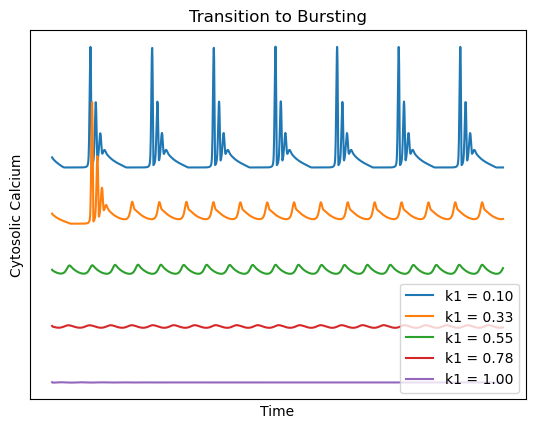

In [20]:
import matplotlib.pyplot as plt

k1_array = linspace(0.1, 1, 5)  # Range of J_in values

for index, k1 in enumerate(k1_array):
    params[0] = k1  # Update k1
    # solution = odeint(model, y0, t, args=(params,))
    solution = solve_ivp(model, t_span, y0, args=(params,), method='BDF', max_step=0.2)

    plt.plot(solution.t, solution.y[2]-5*index, label=f'k1 = {k1:.2f}')

plt.xticks([])
plt.yticks([])
plt.xlabel('Time')
plt.ylabel('Cytosolic Calcium')
plt.legend(loc='lower right')
plt.title('Transition to Bursting')
plt.show()